In [3]:
import pandas as pd
import regex as re
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [4]:
data=pd.read_csv('car_resale_prices.csv')

In [5]:
data.head()

,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra
2,2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
3,3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
4,4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra


In [6]:
data.shape

(17446, 15)

In [7]:
data.isnull().sum()

,0
Unnamed: 0,0
full_name,0
resale_price,0
registered_year,69
engine_capacity,14
insurance,7
transmission_type,0
kms_driven,3
owner_type,45
fuel_type,0


In [8]:
data.isnull().any(axis=1).sum()

np.int64(654)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17446 entries, 0 to 17445
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         17446 non-null  int64  
 1   full_name          17446 non-null  object 
 2   resale_price       17446 non-null  object 
 3   registered_year    17377 non-null  object 
 4   engine_capacity    17432 non-null  object 
 5   insurance          17439 non-null  object 
 6   transmission_type  17446 non-null  object 
 7   kms_driven         17443 non-null  object 
 8   owner_type         17401 non-null  object 
 9   fuel_type          17446 non-null  object 
 10  max_power          17344 non-null  object 
 11  seats              17436 non-null  float64
 12  mileage            16938 non-null  object 
 13  body_type          17446 non-null  object 
 14  city               17446 non-null  object 
dtypes: float64(1), int64(1), object(13)
memory usage: 2.0+ MB


In [10]:
data.resale_price.nunique()

1738

In [11]:
data.resale_price.unique()

array(['₹ 5.45 Lakh', '₹ 10 Lakh', '₹ 4.50 Lakh', ..., '₹ 62.90 Lakh',
       '₹ 26.89 Lakh', '₹ 11.29 Lakh'], dtype=object)

In [12]:
non_lakh=data[~data.resale_price.str.lower().str.contains("lakh",na=False)]
non_lakh.resale_price.unique()

array(['₹ 50,000', '₹ 1.04 Crore', '₹ 60,000', '₹ 1.20 Crore', '₹ 70,000',
       '₹ 80,000', '₹ 64,000', '₹ 67,576', '₹ 90,135', '₹ 81,853',
       '₹ 63,457', '₹ 90,000', '₹ 99,000', '₹ 78,000', '₹ 85,000',
       '₹ 98,657', '₹ 84,000', '₹ 83,632', '₹ 54,000', '₹ 81,000',
       '₹ 74,000', '₹ 1.01 Crore', '₹ 1.11 Crore', '₹ 1.26 Crore',
       '₹ 1.45 Crore', '₹ 2.25 Crore', '₹ 1.57 Crore', '₹ 1.23 Crore',
       '₹ 1.80 Crore', '₹ 1.25 Crore', '₹ 1.05 Crore', '₹ 95,000',
       '₹ 75,000', '₹ 55,000', '₹ 65,000', '₹ 35,000', '₹ 66,000',
       '₹ 62,000', '₹ 69,000', '₹ 57,000', '₹ 72,800', '₹ 75,635',
       '₹ 28,001', '₹ 60,896', '₹ 63,000', '₹ 40,000', '₹ 28,000',
       '₹ 45,000', '₹ 99,999', '₹ 32,000', '₹ 96,107', '₹ 67,500',
       '₹ 30,000', '₹ 76,479', '₹ 98,000', '₹ 1.30 Crore', '₹ 1.22 Crore',
       '₹ 1.15 Crore', '₹ 96,000', '₹ 72,000', '₹ 78,467', '₹ 88,789',
       '₹ 82,000', '₹ 92,293', '₹ 66,988', '₹ 32,397', '₹ 96,090',
       '₹ 92,000', '₹ 94,231', '₹ 1.03

In [13]:
data.resale_price.apply(type).value_counts()

,count
resale_price,
<class 'str'>,17446


In [14]:
def convert_price_float(price_str):
  if pd.isnull(price_str):
    return None

  price=str.lower(price_str).replace("₹","").replace(",","").strip()

  if "lakh" in price:
    return float(price.replace("lakh",""))*100000
  elif "crore" in price:
    return float(price.replace("crore",""))*10000000
  else:
    return float(price)

data.resale_price=data.resale_price.apply(convert_price_float)
data


,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city
0,0,2017 Maruti Baleno 1.2 Alpha,545000.0,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra
1,1,2018 Tata Hexa XTA,1000000.0,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra
2,2,2015 Maruti Swift Dzire VXI,450000.0,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
3,3,2015 Maruti Swift Dzire VXI,450000.0,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
4,4,2009 Hyundai i10 Magna 1.1,160000.0,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17441,17441,2013 Honda Amaze VX i-Vtech,325000.0,Jul 2013,1198 cc,Comprehensive,Manual,"89,000 Kms",Second Owner,Petrol,86.7bhp,5.0,18 kmpl,Sedan,Delhi
17442,17442,2016 Toyota Camry 2.5 Hybrid,2075000.0,Jun 2016,2494 cc,Comprehensive,Automatic,"68,000 Kms",First Owner,Petrol,157.7bhp,5.0,19.16 kmpl,Sedan,Delhi
17443,17443,2016 Toyota Corolla Altis GL MT,835000.0,Jun 2016,1798 cc,Comprehensive,Manual,"81,000 Kms",First Owner,Petrol,138.03bhp,5.0,14.28 kmpl,Sedan,Delhi
17444,17444,2019 Hyundai Creta 1.6 CRDi AT SX Plus,1395000.0,Jun 2019,1582 cc,Comprehensive,Automatic,"20,000 Kms",First Owner,Diesel,126.2bhp,5.0,17.01 kmpl,SUV,Delhi


In [15]:
data.resale_price.dtype

dtype('float64')

In [16]:
data.engine_capacity=data.engine_capacity.str.replace("cc","").str.strip().astype(float)
data.engine_capacity

,engine_capacity
0,1197.0
1,2179.0
2,1197.0
3,1197.0
4,1086.0
...,...
17441,1198.0
17442,2494.0
17443,1798.0
17444,1582.0


In [17]:
data.kms_driven=data.kms_driven.str.lower().str.replace(",","").str.replace("kms","").str.strip().astype(float)
data.kms_driven

,kms_driven
0,40000.0
1,70000.0
2,70000.0
3,70000.0
4,80000.0
...,...
17441,89000.0
17442,68000.0
17443,81000.0
17444,20000.0


In [18]:
data.max_power[~data.max_power.str.lower().str.contains("bhp",na=False)]

,max_power
22,170PS
25,170PS
45,102
46,90 PS
47,90 PS
...,...
17109,92
17112,90 PS
17203,"118PS at 6,600 rpm"
17353,"118PS at 6,600 rpm"


In [19]:
data.max_power[22]

'170PS'

In [20]:
def max_power_to_float(power):
    if pd.isnull(power):
        return None

    power= str(power).lower()

    if "bhp" in power:
        return round(float(re.search(r'[\d.]+', power).group()), 1)
    elif "ps" in power:
        return round(float(re.search(r'[\d.]+', power).group()) * 0.98632, 1)
    else:
        return round(float(re.search(r'[\d.]+', power).group()), 1)


In [21]:
data.max_power=data.max_power.apply(max_power_to_float)

In [22]:
data.max_power[22]

np.float64(167.7)

In [23]:
data.fuel_type.unique()

array(['Petrol', 'Diesel', 'CNG', 'Electric', 'LPG'], dtype=object)

In [24]:
data[data.fuel_type=="Electric"].shape[0]

61

In [25]:
data[data.fuel_type=="Electric"].mileage.isnull().sum()

np.int64(53)

In [26]:
data[(data.fuel_type=="Electric")&(data.mileage.notnull())].mileage

,mileage
3437,110 kmpl
6341,110 kmpl
6358,110 kmpl
8857,120 kmpl
10558,140 kmpl
14181,140 kmpl
14193,140 kmpl
17095,110 kmpl


In [27]:
data.mileage[~data.mileage.str.lower().str.contains("kmpl",na=True)].shape[0]

151

In [28]:
data[(data.fuel_type=="CNG")|(data.fuel_type=="LPG")].shape[0]

533

In [29]:
data[((data.fuel_type=="CNG")|(data.fuel_type=="LPG"))&(data.mileage.notnull())].mileage

,mileage
16,26.6 kmpl
49,21.94 km/kg
50,21.94 km/kg
51,21.94 km/kg
91,26.2 kmpl
...,...
17258,32.52 kmpl
17286,26.11 kmpl
17352,32.52 kmpl
17370,14.53 kmpl


In [30]:
from numpy import e
def convert_mileage(d):
  if pd.isnull(d.mileage):
    return None
  if d.fuel_type=="CNG":
    if "km/kg" in d.mileage.lower():
      return round(float(d.mileage.lower().replace("km/kg",""))*0.72,1)
    else:
      return round(float(d.mileage.lower().replace("kmpl","")),1)
  elif d.fuel_type=="LPG":
    if "km/kg" in d.mileage.lower():
      return round(float(d.mileage.lower().replace("km/kg",""))*0.54,1)
    else:
      return round(float(d.mileage.lower().replace("kmpl","")),1)
  elif d.fuel_type=="Electric":
    return round(float(d.mileage.lower().replace("kmpl","")),1)
  else:
    return round(float(d.mileage.lower().replace("kmpl","")),1)

In [31]:
data["mileage"]=data.apply(convert_mileage,axis=1)


In [32]:
data

,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city
0,0,2017 Maruti Baleno 1.2 Alpha,545000.0,2017,1197.0,Third Party insurance,Manual,40000.0,First Owner,Petrol,83.1,5.0,21.4,Hatchback,Agra
1,1,2018 Tata Hexa XTA,1000000.0,2018,2179.0,Third Party insurance,Automatic,70000.0,First Owner,Diesel,153.9,7.0,17.6,MUV,Agra
2,2,2015 Maruti Swift Dzire VXI,450000.0,2015,1197.0,Third Party insurance,Manual,70000.0,Second Owner,Petrol,83.1,5.0,20.9,Sedan,Agra
3,3,2015 Maruti Swift Dzire VXI,450000.0,2015,1197.0,Third Party insurance,Manual,70000.0,Second Owner,Petrol,83.1,5.0,20.9,Sedan,Agra
4,4,2009 Hyundai i10 Magna 1.1,160000.0,2009,1086.0,Third Party insurance,Manual,80000.0,First Owner,Petrol,68.0,5.0,19.8,Hatchback,Agra
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17441,17441,2013 Honda Amaze VX i-Vtech,325000.0,Jul 2013,1198.0,Comprehensive,Manual,89000.0,Second Owner,Petrol,86.7,5.0,18.0,Sedan,Delhi
17442,17442,2016 Toyota Camry 2.5 Hybrid,2075000.0,Jun 2016,2494.0,Comprehensive,Automatic,68000.0,First Owner,Petrol,157.7,5.0,19.2,Sedan,Delhi
17443,17443,2016 Toyota Corolla Altis GL MT,835000.0,Jun 2016,1798.0,Comprehensive,Manual,81000.0,First Owner,Petrol,138.0,5.0,14.3,Sedan,Delhi
17444,17444,2019 Hyundai Creta 1.6 CRDi AT SX Plus,1395000.0,Jun 2019,1582.0,Comprehensive,Automatic,20000.0,First Owner,Diesel,126.2,5.0,17.0,SUV,Delhi


In [33]:
def date(y):
  if pd.isnull(y):
    return None
  if type(y)==str:
    return int(re.search(r'\d+',y).group())
  else:
    return int(y)

In [34]:
data.registered_year=data["registered_year"].apply(date)


In [35]:
data.registered_year

,registered_year
0,2017.0
1,2018.0
2,2015.0
3,2015.0
4,2009.0
...,...
17441,2013.0
17442,2016.0
17443,2016.0
17444,2019.0


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17446 entries, 0 to 17445
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         17446 non-null  int64  
 1   full_name          17446 non-null  object 
 2   resale_price       17446 non-null  float64
 3   registered_year    17377 non-null  float64
 4   engine_capacity    17432 non-null  float64
 5   insurance          17439 non-null  object 
 6   transmission_type  17446 non-null  object 
 7   kms_driven         17443 non-null  float64
 8   owner_type         17401 non-null  object 
 9   fuel_type          17446 non-null  object 
 10  max_power          17344 non-null  float64
 11  seats              17436 non-null  float64
 12  mileage            16938 non-null  float64
 13  body_type          17446 non-null  object 
 14  city               17446 non-null  object 
dtypes: float64(7), int64(1), object(7)
memory usage: 2.0+ MB


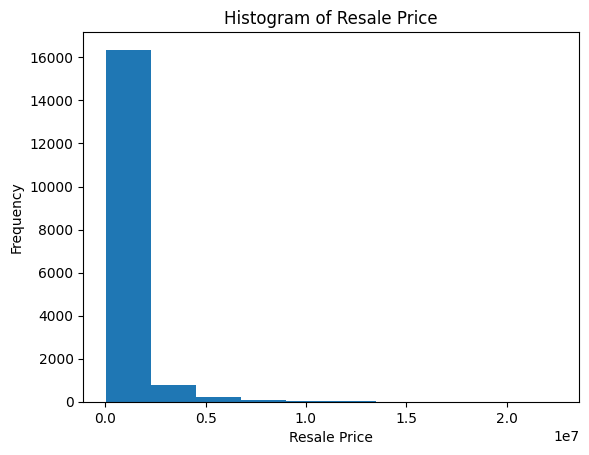

In [37]:
plt.hist(data['resale_price'])
plt.xlabel('Resale Price')
plt.ylabel('Frequency')
plt.title('Histogram of Resale Price')
plt.show()

In [38]:
data['resale_price_log'] = np.log1p(data['resale_price'])

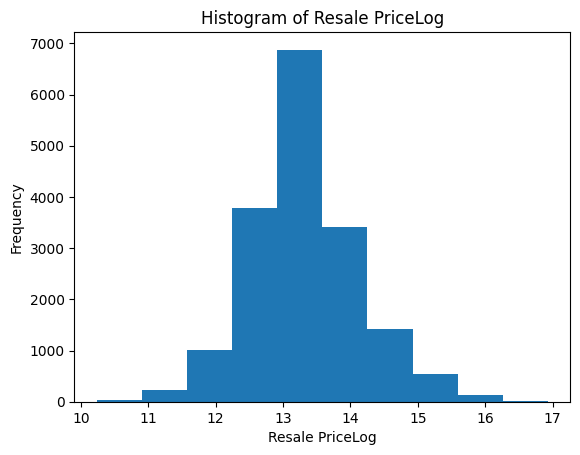

In [39]:
plt.hist(data['resale_price_log'])
plt.xlabel('Resale PriceLog')
plt.ylabel('Frequency')
plt.title('Histogram of Resale PriceLog')
plt.show()

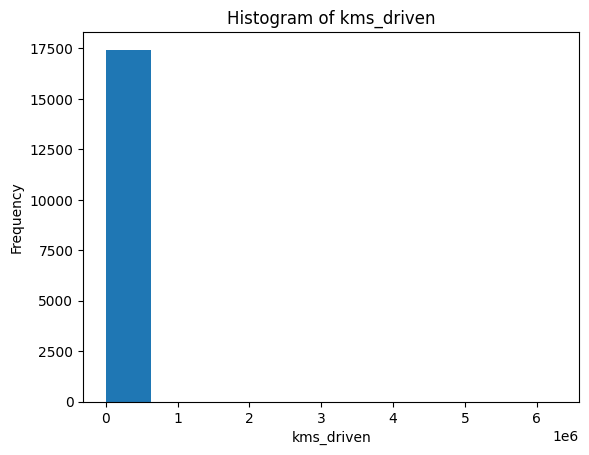

In [40]:
plt.hist(data['kms_driven'])
plt.xlabel('kms_driven')
plt.ylabel('Frequency')
plt.title('Histogram of kms_driven')
plt.show()

In [41]:
data['kms_driven_log'] = np.log1p(data['kms_driven'])

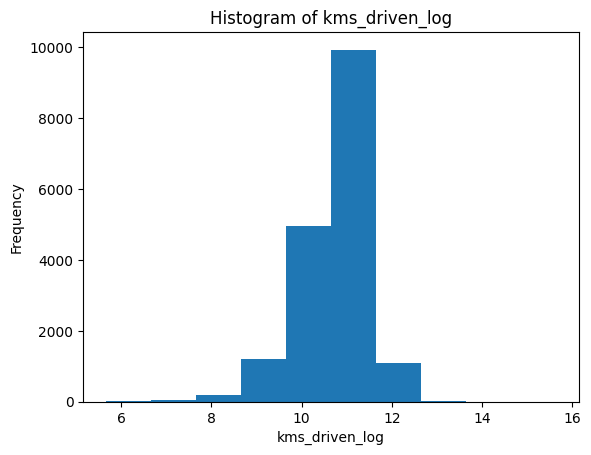

In [42]:
plt.hist(data['kms_driven_log'])
plt.xlabel('kms_driven_log')
plt.ylabel('Frequency')
plt.title('Histogram of kms_driven_log')
plt.show()

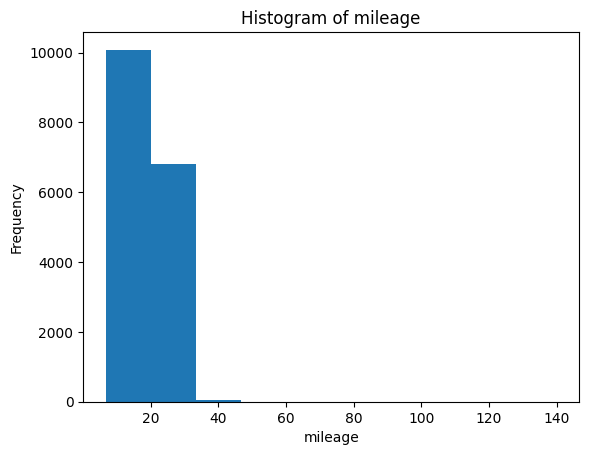

In [43]:
plt.hist(data['mileage'])
plt.xlabel('mileage')
plt.ylabel('Frequency')
plt.title('Histogram of mileage')
plt.show()

In [44]:
data['mileage_log'] = np.log1p(data['mileage'])

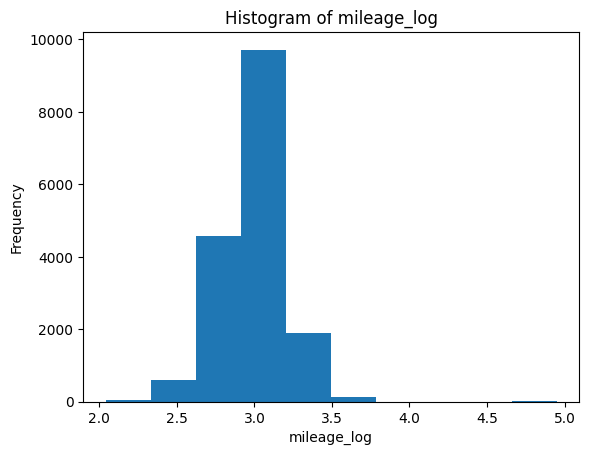

In [45]:
plt.hist(data['mileage_log'])
plt.xlabel('mileage_log')
plt.ylabel('Frequency')
plt.title('Histogram of mileage_log')
plt.show()

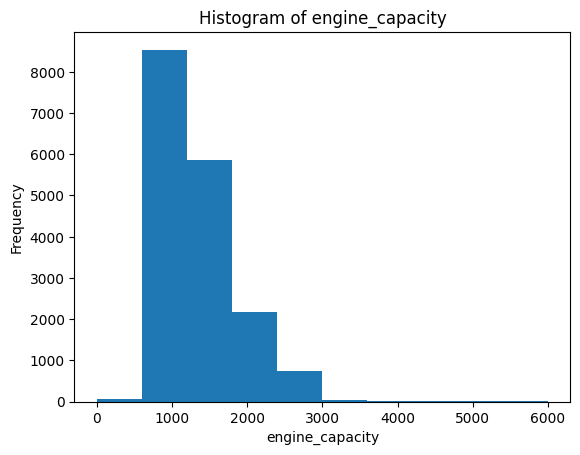

In [46]:
plt.hist(data['engine_capacity'])
plt.xlabel('engine_capacity')
plt.ylabel('Frequency')
plt.title('Histogram of engine_capacity')
plt.show()

In [47]:
data['engine_capacity_log'] = np.log1p(data['engine_capacity'])

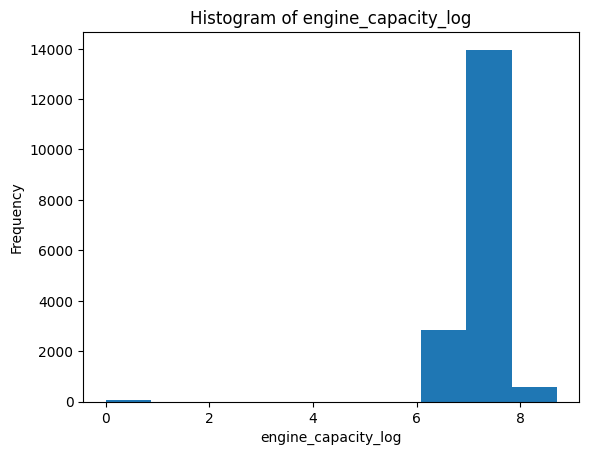

In [48]:
plt.hist(data['engine_capacity_log'])
plt.xlabel('engine_capacity_log')
plt.ylabel('Frequency')
plt.title('Histogram of engine_capacity_log')
plt.show()

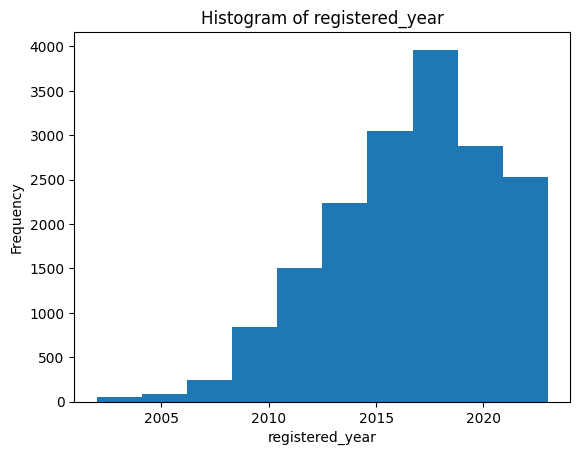

In [49]:
plt.hist(data['registered_year'])
plt.xlabel('registered_year')
plt.ylabel('Frequency')
plt.title('Histogram of registered_year')
plt.show()

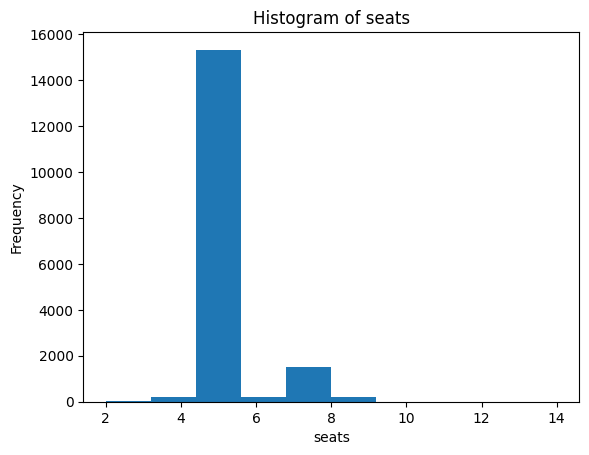

In [50]:
plt.hist(data['seats'])
plt.xlabel('seats')
plt.ylabel('Frequency')
plt.title('Histogram of seats')
plt.show()

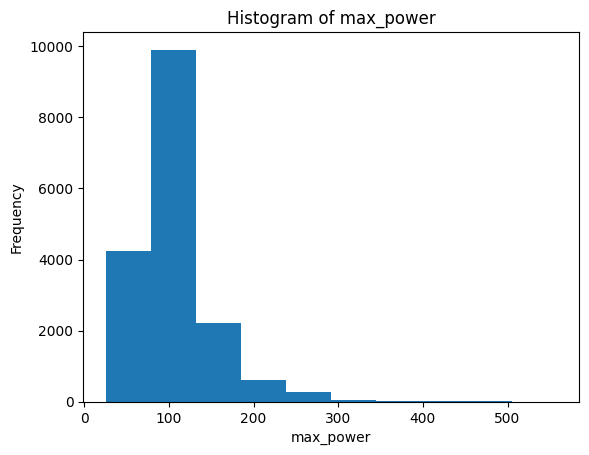

In [51]:
plt.hist(data['max_power'])
plt.xlabel('max_power')
plt.ylabel('Frequency')
plt.title('Histogram of max_power')
plt.show()

In [52]:
data['max_power_log'] = np.log1p(data['max_power'])

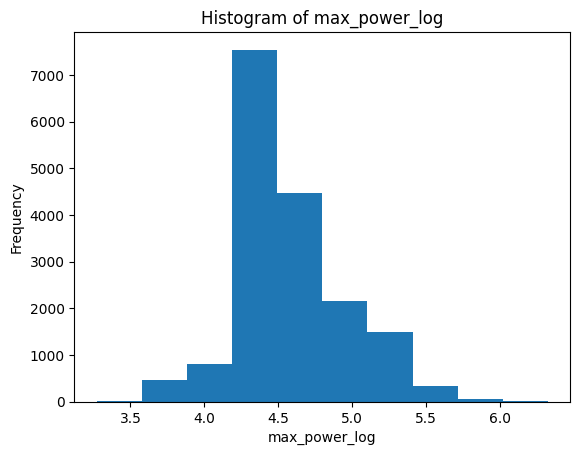

In [53]:
plt.hist(data['max_power_log'])
plt.xlabel('max_power_log')
plt.ylabel('Frequency')
plt.title('Histogram of max_power_log')
plt.show()

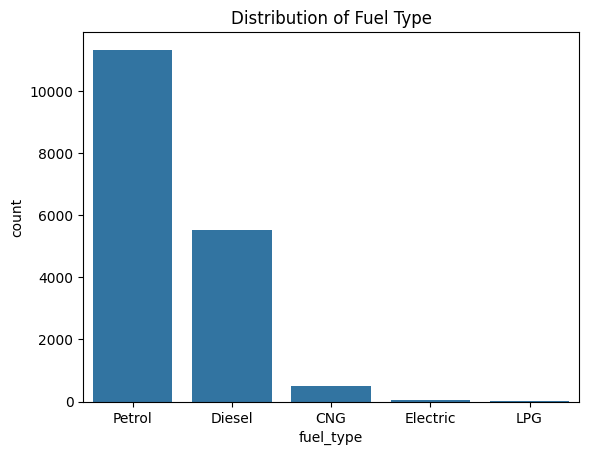

In [54]:
sns.countplot(x=data.fuel_type, data=data)
plt.title('Distribution of Fuel Type')
plt.show()

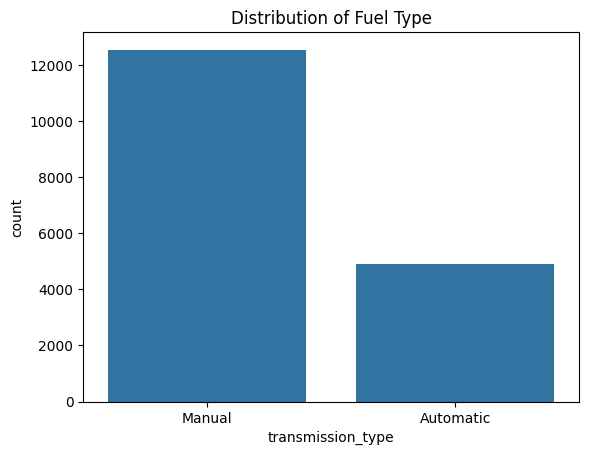

In [55]:
sns.countplot(x=data.transmission_type, data=data)
plt.title('Distribution of Fuel Type')
plt.show()

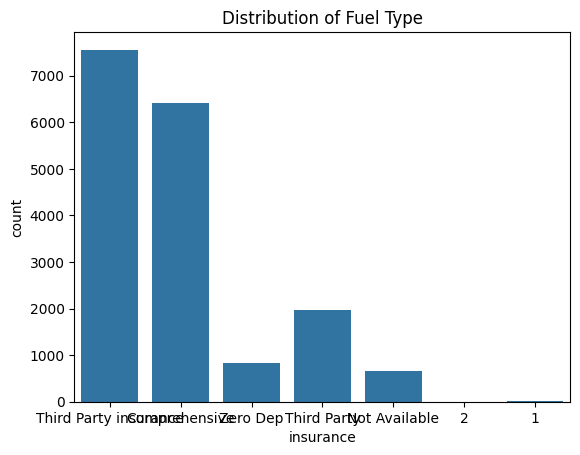

In [56]:
sns.countplot(x=data.insurance, data=data)
plt.title('Distribution of Fuel Type')
plt.show()

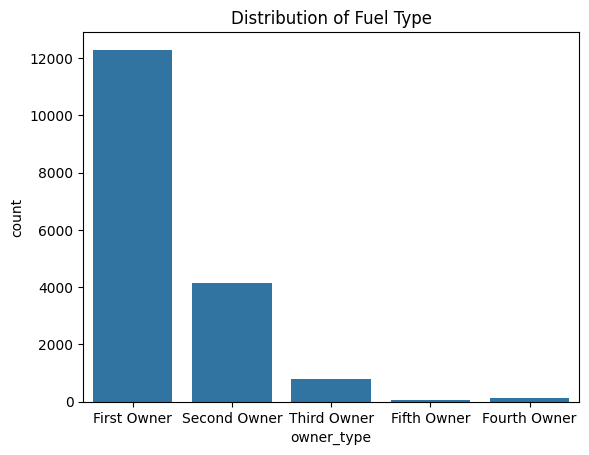

In [57]:
sns.countplot(x=data.owner_type, data=data)
plt.title('Distribution of Fuel Type')
plt.show()

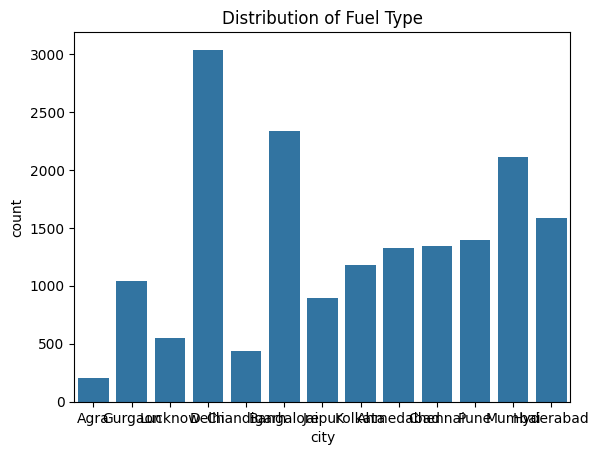

In [58]:
sns.countplot(x=data.city, data=data)
plt.title('Distribution of Fuel Type')
plt.show()

In [59]:
data.body_type.value_counts()

,count
body_type,
Hatchback,7343
Sedan,4781
SUV,4406
MUV,759
Minivans,65
Maruti,19
Pickup,13
Coupe,10
Cars,8


In [60]:
luxury_cars = ['Mercedes-Benz', 'Jaguar', 'BMW', 'Audi', 'Volvo']
mid_range_cars=['Honda', 'Mahindra', 'Chevrolet', 'Tata']
affordable_cars=["Maruti","Datsun",'Hyundai','Skoda','Isuzu']


In [61]:
data['body_type'].value_counts().Hatchback

np.int64(7343)

In [62]:
def body(b):
  if data['body_type'].value_counts()[b]<100:
    if b in luxury_cars:
      return "luxury_car_body"
    elif b in mid_range_cars:
      return "mid_range_car_body"
    else:
      return "affordable_car_body"
  else:
    return b

In [63]:
data.body_type=data.body_type.apply(body)

In [64]:
data.body_type.value_counts()

,count
body_type,
Hatchback,7343
Sedan,4781
SUV,4406
MUV,759
affordable_car_body,128
mid_range_car_body,16
luxury_car_body,13


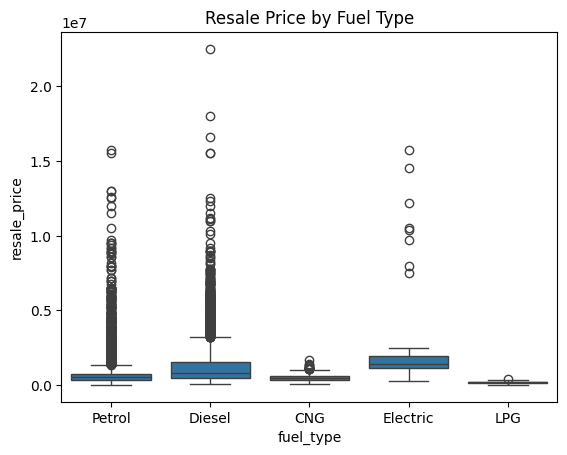

In [65]:
sns.boxplot(x=data.fuel_type, y=data.resale_price, data=data)
plt.title('Resale Price by Fuel Type')
plt.show()

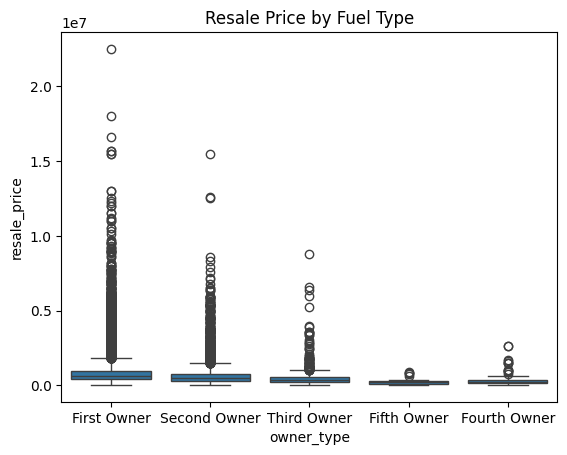

In [66]:
sns.boxplot(x=data.owner_type, y=data.resale_price, data=data)
plt.title('Resale Price by Fuel Type')
plt.show()

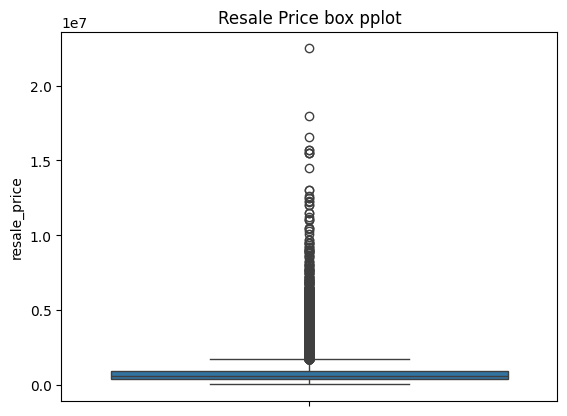

In [67]:
sns.boxplot(y=data.resale_price)
plt.title('Resale Price box pplot')
plt.show()

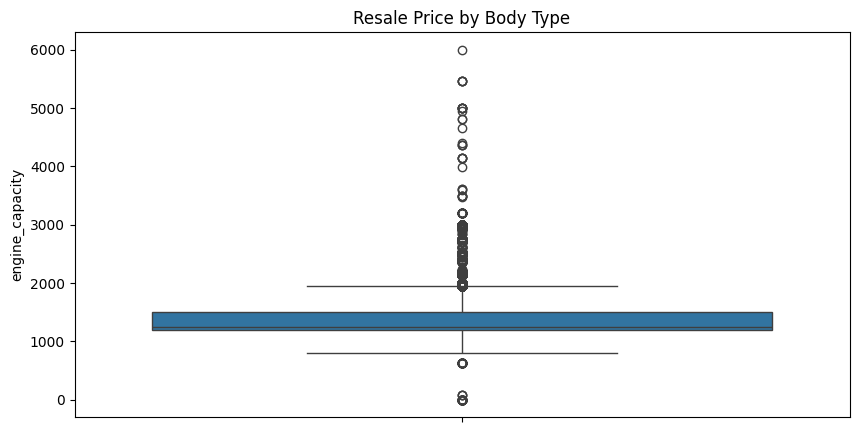

In [68]:
plt.figure(figsize=(10, 5))
sns.boxplot(y=data.engine_capacity, data=data)
plt.title('Resale Price by Body Type')
plt.show()

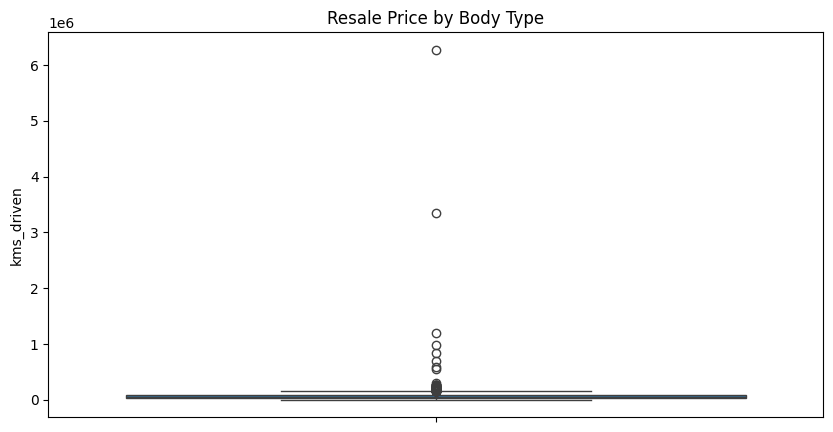

In [69]:
plt.figure(figsize=(10, 5))
sns.boxplot(y=data.kms_driven, data=data)
plt.title('Resale Price by Body Type')
plt.show()

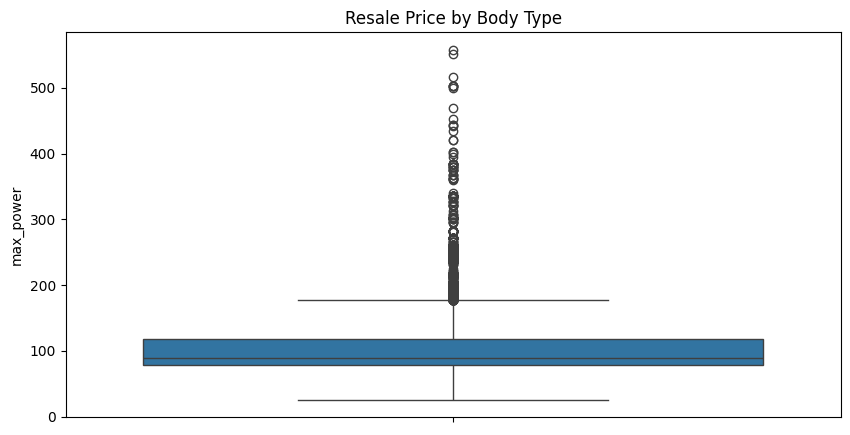

In [70]:
plt.figure(figsize=(10, 5))
sns.boxplot(y=data.max_power, data=data)
plt.title('Resale Price by Body Type')
plt.show()

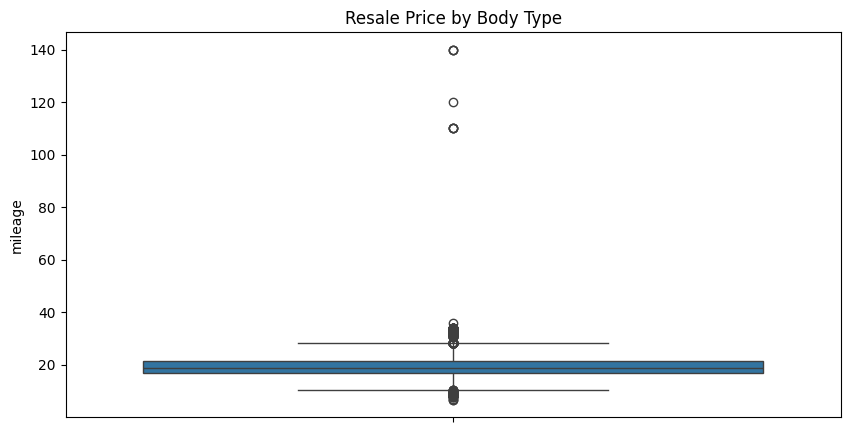

In [71]:
plt.figure(figsize=(10, 5))
sns.boxplot(y=data.mileage, data=data)
plt.title('Resale Price by Body Type')
plt.show()

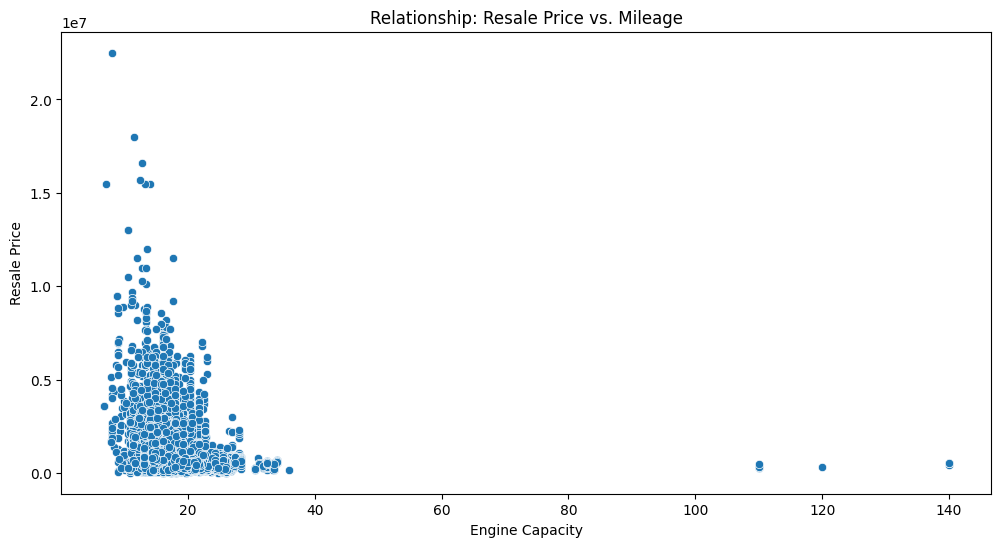

In [72]:
plt.figure(figsize=(12, 6))

sns.scatterplot(x='mileage', y='resale_price', data=data)

plt.title('Relationship: Resale Price vs. Mileage')
plt.xlabel('Engine Capacity')
plt.ylabel('Resale Price')
plt.show()

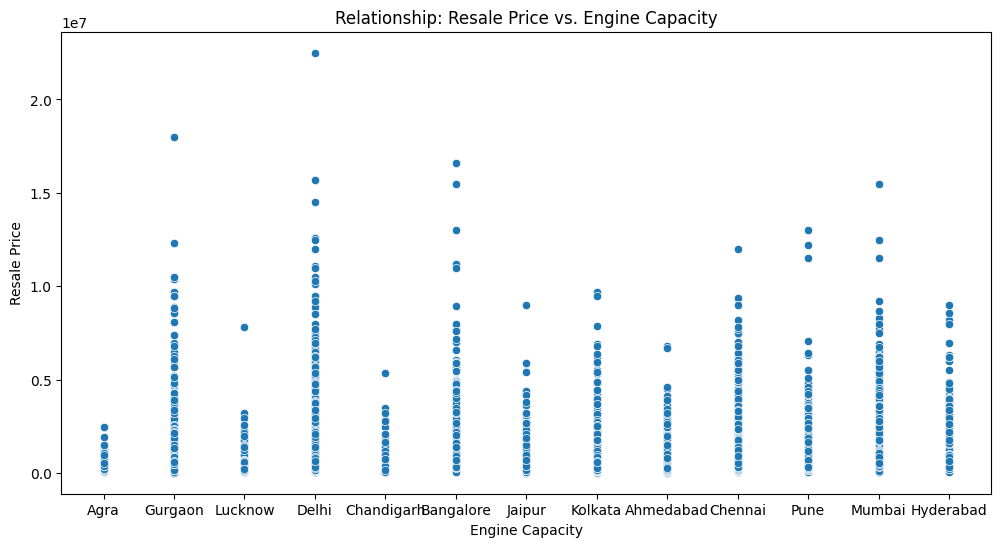

In [73]:
plt.figure(figsize=(12, 6))

sns.scatterplot(x='city', y='resale_price', data=data)

plt.title('Relationship: Resale Price vs. Engine Capacity')
plt.xlabel('Engine Capacity')
plt.ylabel('Resale Price')
plt.show()

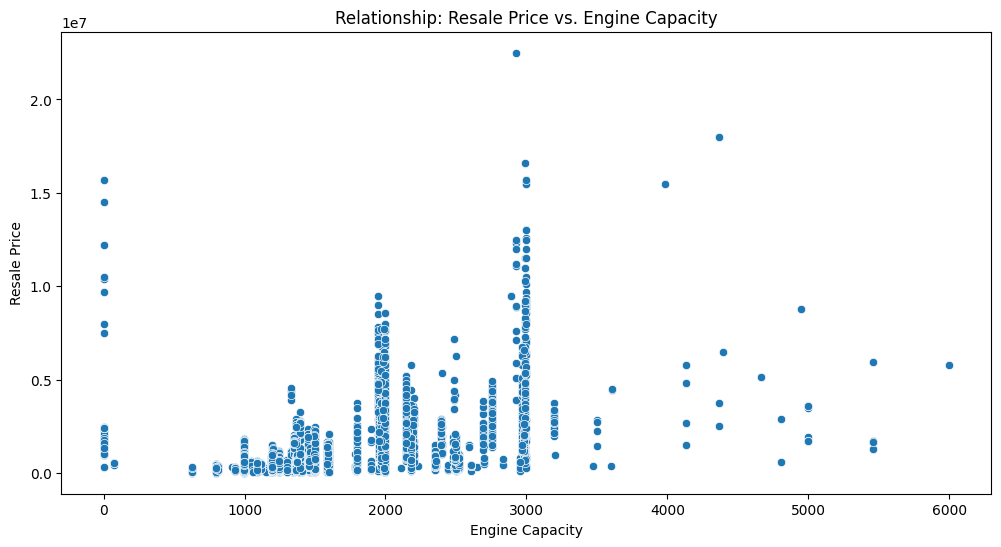

In [74]:
plt.figure(figsize=(12, 6))

sns.scatterplot(x='engine_capacity', y='resale_price', data=data)

plt.title('Relationship: Resale Price vs. Engine Capacity')
plt.xlabel('Engine Capacity')
plt.ylabel('Resale Price')
plt.show()

In [75]:
data.owner_type.isnull().sum()

np.int64(45)

<Axes: >

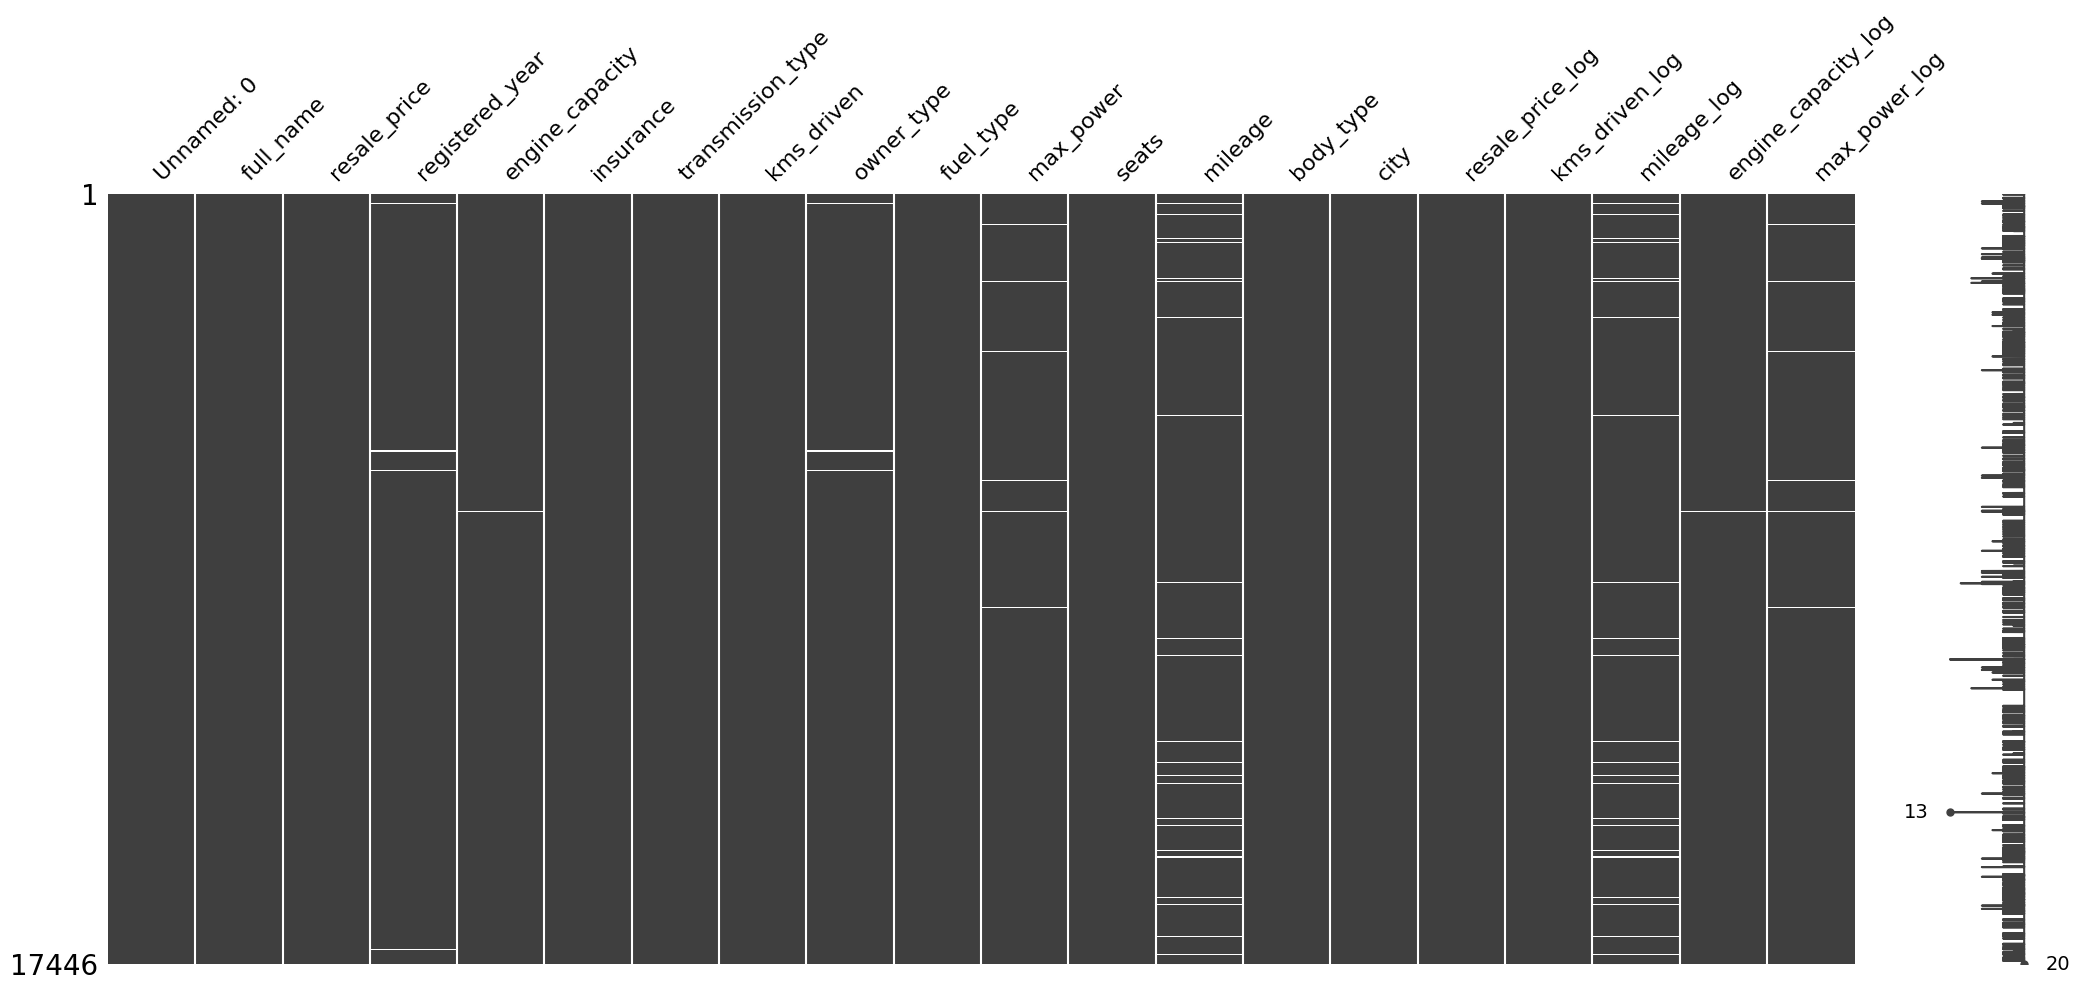

In [76]:
msno.matrix(data)

<Axes: >

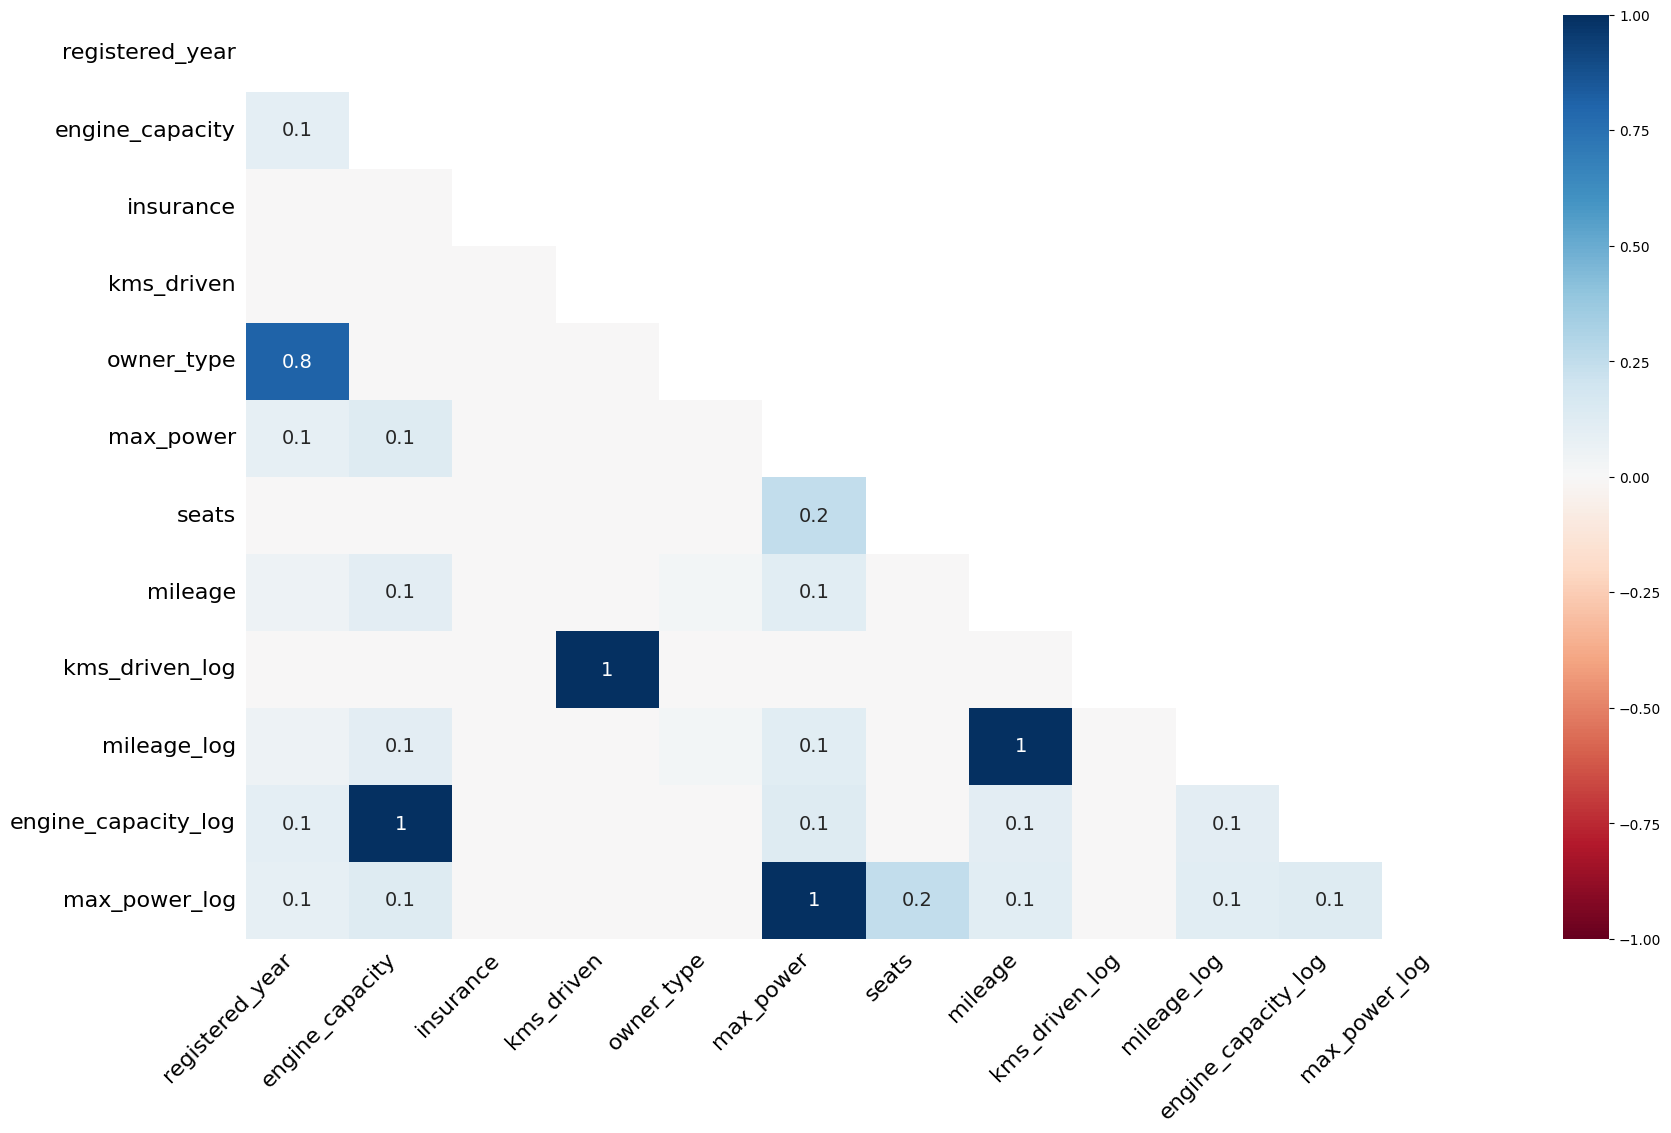

In [77]:
msno.heatmap(data)

In [78]:
data.dropna(inplace=True)

In [79]:
data.isnull().sum()

,0
Unnamed: 0,0
full_name,0
resale_price,0
registered_year,0
engine_capacity,0
insurance,0
transmission_type,0
kms_driven,0
owner_type,0
fuel_type,0


In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16792 entries, 0 to 17445
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           16792 non-null  int64  
 1   full_name            16792 non-null  object 
 2   resale_price         16792 non-null  float64
 3   registered_year      16792 non-null  float64
 4   engine_capacity      16792 non-null  float64
 5   insurance            16792 non-null  object 
 6   transmission_type    16792 non-null  object 
 7   kms_driven           16792 non-null  float64
 8   owner_type           16792 non-null  object 
 9   fuel_type            16792 non-null  object 
 10  max_power            16792 non-null  float64
 11  seats                16792 non-null  float64
 12  mileage              16792 non-null  float64
 13  body_type            16792 non-null  object 
 14  city                 16792 non-null  object 
 15  resale_price_log     16792 non-null  floa

In [81]:
data = pd.get_dummies(data,columns=['owner_type'],drop_first=True,dtype=int)

In [82]:
data.drop(data[data['insurance'].isin(['1', '2'])].index, inplace=True)

In [83]:
data.insurance.value_counts()

,count
insurance,
Third Party insurance,7230
Comprehensive,6178
Third Party,1930
Zero Dep,819
Not Available,627


In [84]:
data = pd.get_dummies(data,columns=['insurance'],drop_first=True,dtype=int)

In [85]:
data = data.drop('full_name', axis=1)

In [86]:
data = data.drop('Unnamed: 0', axis=1)

In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16784 entries, 0 to 17445
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   resale_price                     16784 non-null  float64
 1   registered_year                  16784 non-null  float64
 2   engine_capacity                  16784 non-null  float64
 3   transmission_type                16784 non-null  object 
 4   kms_driven                       16784 non-null  float64
 5   fuel_type                        16784 non-null  object 
 6   max_power                        16784 non-null  float64
 7   seats                            16784 non-null  float64
 8   mileage                          16784 non-null  float64
 9   body_type                        16784 non-null  object 
 10  city                             16784 non-null  object 
 11  resale_price_log                 16784 non-null  float64
 12  kms_driven_log         

In [88]:
data['resale_price_log'] = np.log1p(data['resale_price'])
data['max_power_log'] = np.log1p(data['max_power'])
data['engine_capacity_log'] = np.log1p(data['engine_capacity'])

Splitting the data into training and testing sets

In [89]:
X = data.drop(['resale_price','engine_capacity','kms_driven','max_power','mileage','resale_price_log'], axis=1)
y = data['resale_price_log']

In [90]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

In [91]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['transmission_type', 'fuel_type', 'city', 'body_type']

encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)
X_train_cat = encoder.fit_transform(X_train[cat_cols])

X_test_cat = encoder.transform(X_test[cat_cols])

cat_feature_names = encoder.get_feature_names_out(cat_cols)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=cat_feature_names,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=cat_feature_names,
    index=X_test.index
)

X_train = X_train.drop(columns=cat_cols)
X_test  = X_test.drop(columns=cat_cols)

X_train = pd.concat([X_train, X_train_cat], axis=1)
X_test  = pd.concat([X_test,  X_test_cat], axis=1)


In [92]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13427 entries, 16008 to 2844
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   registered_year                  13427 non-null  float64
 1   seats                            13427 non-null  float64
 2   kms_driven_log                   13427 non-null  float64
 3   mileage_log                      13427 non-null  float64
 4   engine_capacity_log              13427 non-null  float64
 5   max_power_log                    13427 non-null  float64
 6   owner_type_First Owner           13427 non-null  int64  
 7   owner_type_Fourth Owner          13427 non-null  int64  
 8   owner_type_Second Owner          13427 non-null  int64  
 9   owner_type_Third Owner           13427 non-null  int64  
 10  insurance_Not Available          13427 non-null  int64  
 11  insurance_Third Party            13427 non-null  int64  
 12  insurance_Third Part

In [93]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.fit_transform(X_test)

In [94]:
X_train_scaled

array([[-0.65173419, -0.31417536,  0.35728722, ..., -0.08122313,
        -0.02863418, -0.03113096],
       [ 1.58934013, -0.31417536, -0.66107628, ..., -0.08122313,
        -0.02863418, -0.03113096],
       [-0.09146561, -0.31417536, -0.12380683, ..., -0.08122313,
        -0.02863418, -0.03113096],
       ...,
       [ 0.18866868, -0.31417536,  0.31128846, ..., -0.08122313,
        -0.02863418, -0.03113096],
       [ 1.86947442, -0.31417536,  0.01648992, ..., -0.08122313,
        -0.02863418, -0.03113096],
       [-0.93186848, -0.31417536,  0.90508725, ..., -0.08122313,
        -0.02863418, -0.03113096]])

Linear Regression

In [95]:
from sklearn.linear_model import LinearRegression
Linear_Regression = LinearRegression()

In [96]:
Linear_Regression.fit(X_train_scaled,y_train)

LinearRegression()

In [97]:
y_pred = Linear_Regression.predict(X_test_scaled)

In [98]:
pd.DataFrame({'Actual': y_test.round(2), 'Predicted': y_pred.round(2)})

,Actual,Predicted
3290,12.52,12.91
395,13.37,13.34
12195,13.64,13.66
3000,11.92,11.17
2385,13.77,13.82
...,...,...
267,12.77,12.83
5062,13.42,13.82
14445,14.60,14.86
11997,13.00,12.80


In [99]:
round(Linear_Regression.score(X_train_scaled,y_train),2)

0.89

In [100]:
round(Linear_Regression.score(X_test_scaled,y_test),2)

0.88

In [101]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Mean Squared Error: ", round(mean_squared_error(y_test, y_pred),2))
print('Mean Absolute Error: ', round(mean_absolute_error(y_test, y_pred),2))
print('Root Mean Squared Error: ', round(np.sqrt(mean_squared_error(y_test, y_pred)),2))

Mean Squared Error:  0.07
Mean Absolute Error:  0.2
Root Mean Squared Error:  0.26


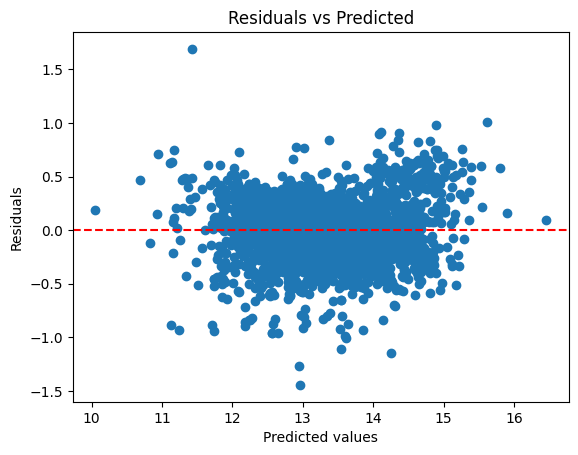

In [102]:
# Linearity
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

In [103]:
import statsmodels.api as sm
X2 = sm.add_constant(X_test_scaled)
model = sm.OLS(y_test, X2).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       resale_price_log   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     723.4
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:02:14   Log-Likelihood:                -228.92
No. Observations:                3357   AIC:                             531.8
Df Residuals:                    3320   BIC:                             758.2
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.2927      0.004   2956.672      0.0

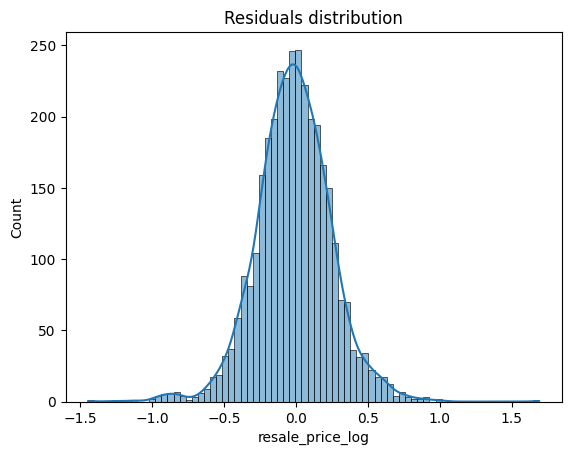

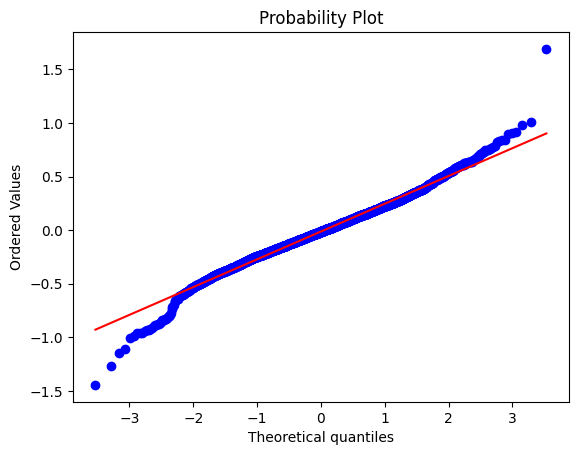

In [104]:
import scipy.stats as stats

sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")
plt.show()

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

In [105]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_test.columns
vif_data["VIF"] = [variance_inflation_factor(X_test_scaled, i) for i in range(X_test_scaled.shape[1])]
print(vif_data)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


                            Feature         VIF
0                   registered_year    2.127217
1                             seats    2.571880
2                    kms_driven_log    1.717493
3                       mileage_log    3.415494
4               engine_capacity_log    9.272237
5                     max_power_log    7.630515
6            owner_type_First Owner  238.876750
7           owner_type_Fourth Owner   12.204063
8           owner_type_Second Owner  207.809381
9            owner_type_Third Owner   50.230107
10          insurance_Not Available    1.176520
11            insurance_Third Party    1.222447
12  insurance_Third Party insurance    1.382665
13               insurance_Zero Dep    1.132089
14         transmission_type_Manual    1.424361
15                 fuel_type_Diesel   10.462148
16               fuel_type_Electric         NaN
17                    fuel_type_LPG    1.104075
18                 fuel_type_Petrol   10.307366
19                   city_Ahmedabad    6

In [106]:
numeric_cols = X_test.select_dtypes(include=['float64'])


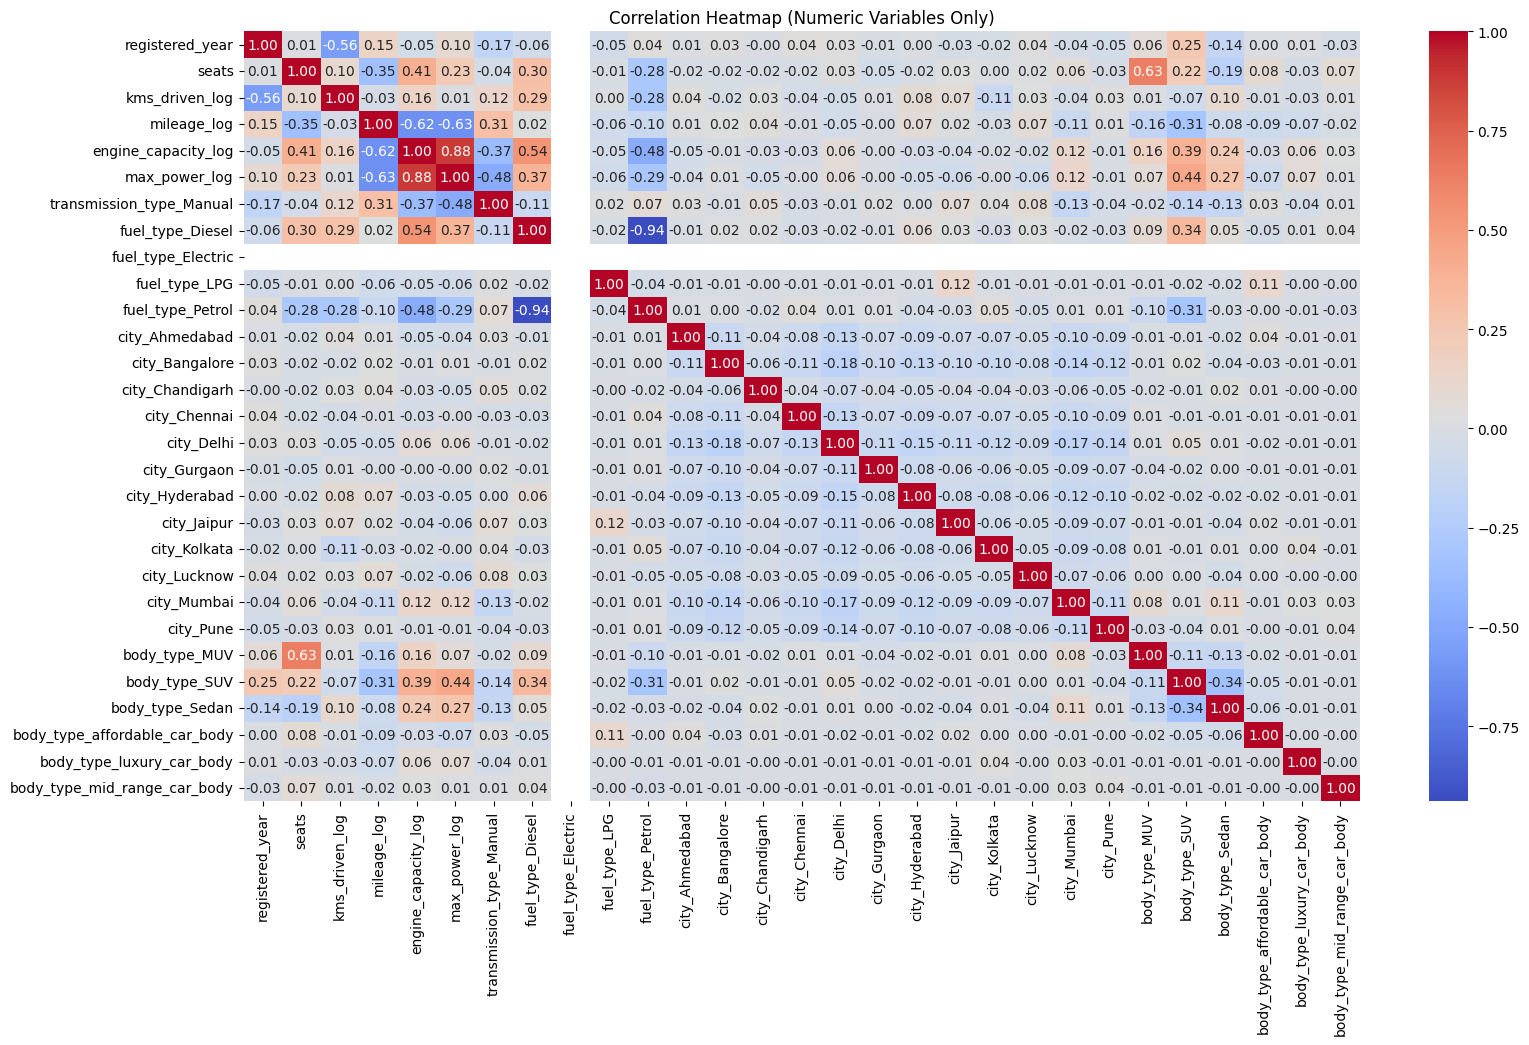

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap (Numeric Variables Only)")
plt.show()

In [108]:
data['engine_power_combined'] = (data['max_power_log'] + data['engine_capacity_log']) / 2

Recheckng

In [109]:
X = data.drop(['resale_price','max_power_log','engine_capacity_log','engine_capacity','kms_driven','max_power','mileage','resale_price_log'], axis=1)
y = data['resale_price_log']

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

In [111]:
cat_cols = ['transmission_type', 'fuel_type', 'city', 'body_type']

encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

X_train_cat = encoder.fit_transform(X_train[cat_cols])

X_test_cat = encoder.transform(X_test[cat_cols])

cat_feature_names = encoder.get_feature_names_out(cat_cols)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=cat_feature_names,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=cat_feature_names,
    index=X_test.index
)
X_train = X_train.drop(columns=cat_cols)
X_test  = X_test.drop(columns=cat_cols)

X_train = pd.concat([X_train, X_train_cat], axis=1)
X_test  = pd.concat([X_test,  X_test_cat], axis=1)


In [112]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.fit_transform(X_test)

2nd time Linear Regression

In [113]:
Linear_Regression = LinearRegression()

In [114]:
Linear_Regression.fit(X_train_scaled,y_train)

LinearRegression()

In [115]:
y_pred = Linear_Regression.predict(X_test_scaled)

In [116]:
round(Linear_Regression.score(X_train_scaled,y_train),2)

0.88

In [117]:
round(Linear_Regression.score(X_test_scaled,y_test),2)

0.88

In [118]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Mean Squared Error: ", round(mean_squared_error(y_test, y_pred),2))
print('Mean Absolute Error: ', round(mean_absolute_error(y_test, y_pred),2))
print('Root Mean Squared Error: ', round(np.sqrt(mean_squared_error(y_test, y_pred)),2))

Mean Squared Error:  0.07
Mean Absolute Error:  0.21
Root Mean Squared Error:  0.27


In [119]:
coefficients = Linear_Regression.coef_
intercept = Linear_Regression.intercept_

import pandas as pd
coef_df = pd.DataFrame({
    'Predictor': X_train.columns,
    'Coefficient': coefficients
})
print("Intercept:", intercept)
print(coef_df)

Intercept: 13.305917704513643
                          Predictor  Coefficient
0                   registered_year     0.385726
1                             seats    -0.040778
2                    kms_driven_log    -0.033738
3                       mileage_log     0.021471
4            owner_type_First Owner     0.120049
5           owner_type_Fourth Owner     0.002838
6           owner_type_Second Owner     0.089711
7            owner_type_Third Owner     0.020004
8           insurance_Not Available    -0.035933
9             insurance_Third Party    -0.022219
10  insurance_Third Party insurance    -0.039320
11               insurance_Zero Dep    -0.017935
12            engine_power_combined     0.503832
13         transmission_type_Manual    -0.099353
14                 fuel_type_Diesel    -0.031413
15               fuel_type_Electric     0.053240
16                    fuel_type_LPG    -0.003270
17                 fuel_type_Petrol    -0.081970
18                   city_Ahmedabad    

In [120]:
numeric_cols = X_test.select_dtypes(include=['float64'])


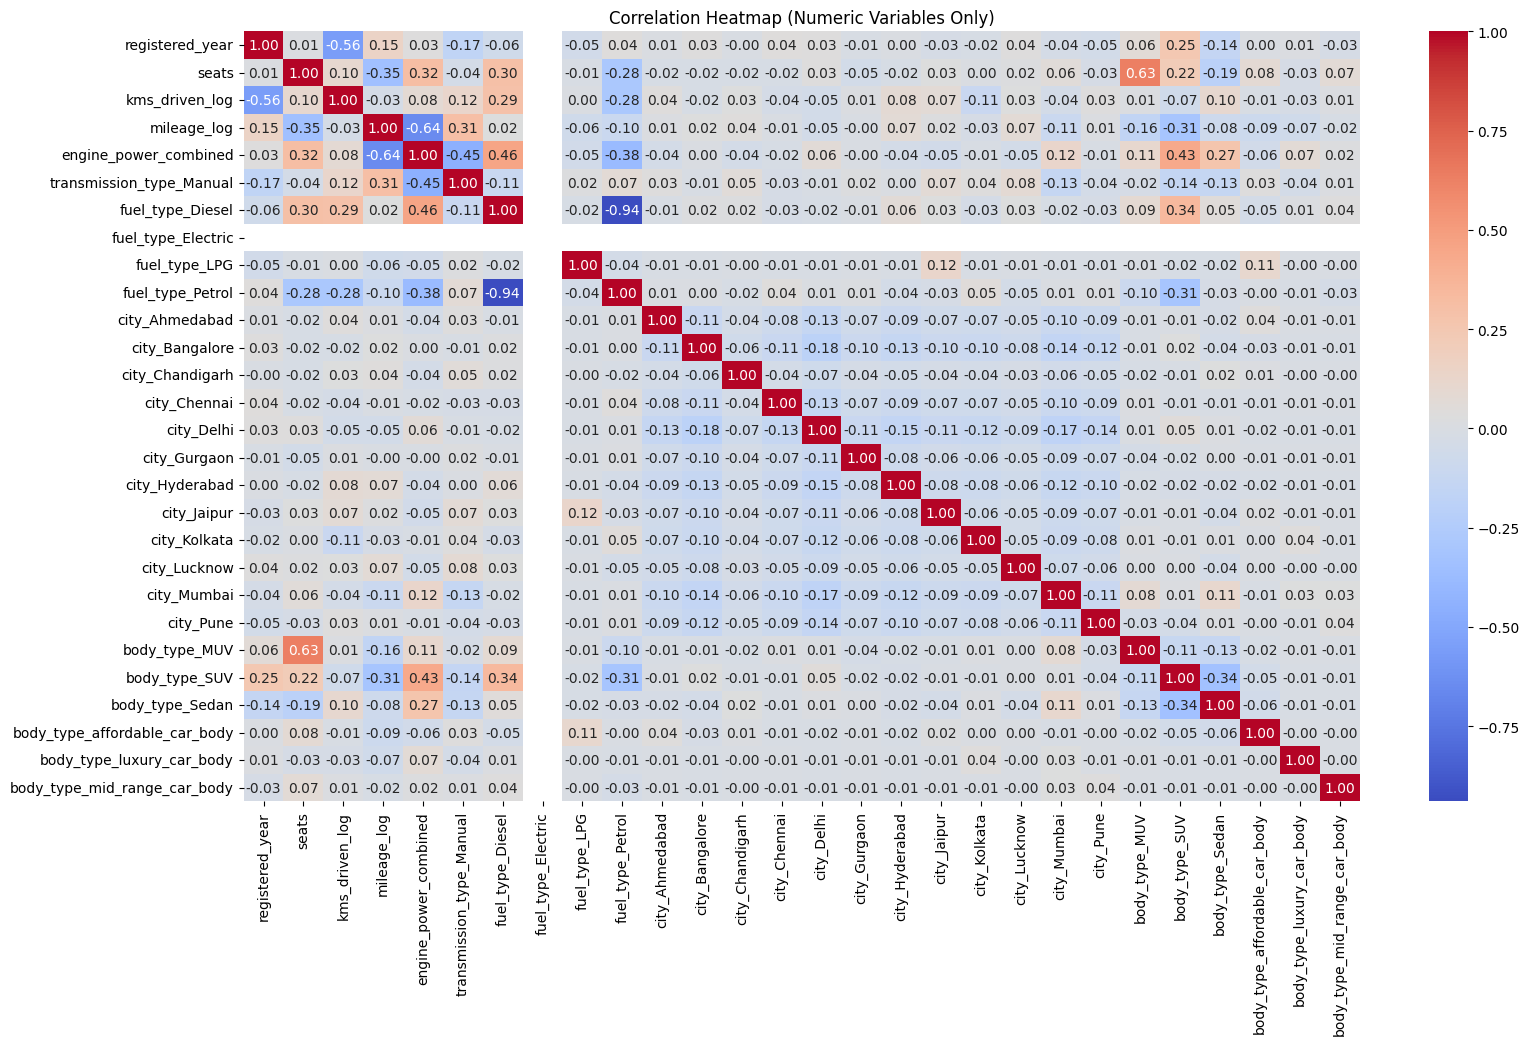

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap (Numeric Variables Only)")
plt.show()

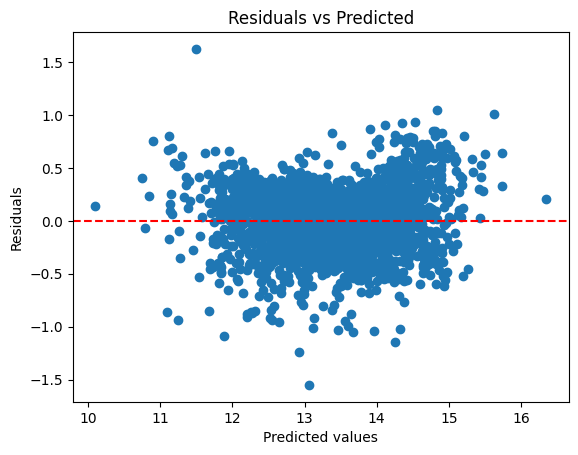

In [122]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

In [123]:
import statsmodels.api as sm
X2 = sm.add_constant(X_test_scaled)
model = sm.OLS(y_test, X2).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       resale_price_log   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     695.7
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:02:19   Log-Likelihood:                -328.94
No. Observations:                3357   AIC:                             729.9
Df Residuals:                    3321   BIC:                             950.2
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.2927      0.005   2870.307      0.0

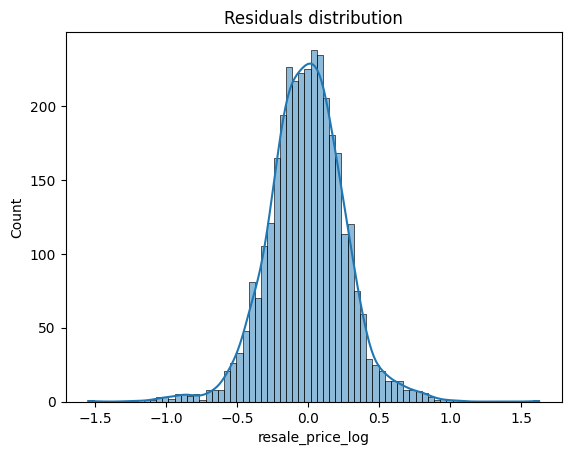

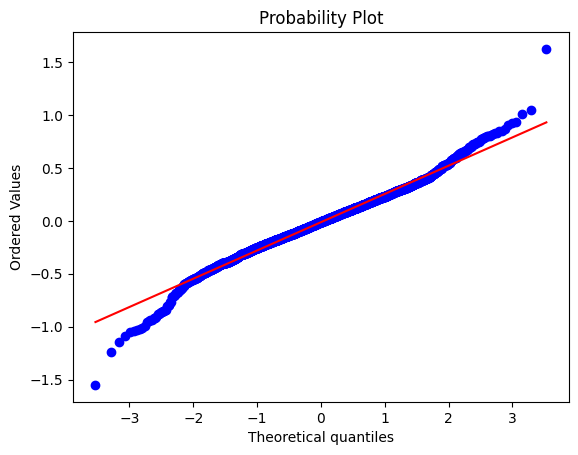

In [124]:
import scipy.stats as stats

sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")
plt.show()

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

In [125]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train_scaled_clean = np.nan_to_num(X_train_scaled)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_test.columns
vif_data["VIF"] = [variance_inflation_factor(X_test_scaled, i) for i in range(X_test_scaled.shape[1])]
print(vif_data)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


                            Feature         VIF
0                   registered_year    2.099993
1                             seats    2.354503
2                    kms_driven_log    1.716404
3                       mileage_log    3.321009
4            owner_type_First Owner  234.395638
5           owner_type_Fourth Owner   11.978390
6           owner_type_Second Owner  203.994551
7            owner_type_Third Owner   49.295954
8           insurance_Not Available    1.176294
9             insurance_Third Party    1.221596
10  insurance_Third Party insurance    1.382613
11               insurance_Zero Dep    1.131744
12            engine_power_combined    4.245811
13         transmission_type_Manual    1.386011
14                 fuel_type_Diesel   10.452219
15               fuel_type_Electric         NaN
16                    fuel_type_LPG    1.101814
17                 fuel_type_Petrol    9.981000
18                   city_Ahmedabad    6.651661
19                   city_Bangalore   11

RIDGE

In [126]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge.score(X_test_scaled, y_test)

0.877782290513512

In [127]:
ridge.score(X_train_scaled, y_train)

0.8811643034920027

In [128]:
y_pred = ridge.predict(X_test_scaled)
print("Mean Squared Error: ", round(mean_squared_error(y_test, y_pred),2))
print('Mean Absolute Error: ', round(mean_absolute_error(y_test, y_pred),2))
print('Root Mean Squared Error: ', round(np.sqrt(mean_squared_error(y_test, y_pred)),2))

Mean Squared Error:  0.07
Mean Absolute Error:  0.21
Root Mean Squared Error:  0.27


In [129]:
ols_coef = pd.Series(
    Linear_Regression.coef_,
    index=X_train.columns
)

ridge_coef = pd.Series(
    ridge.coef_,
    index=X_train.columns
)

pd.concat([ols_coef, ridge_coef], axis=1,
          keys=['OLS', 'Ridge']).sort_values('OLS')

,OLS,Ridge
transmission_type_Manual,-0.099353,-0.099374
fuel_type_Petrol,-0.081970,-0.081904
seats,-0.040778,-0.040769
insurance_Third Party insurance,-0.039320,-0.039336
insurance_Not Available,-0.035933,-0.035936
kms_driven_log,-0.033738,-0.033754
fuel_type_Diesel,-0.031413,-0.031298
body_type_Sedan,-0.026593,-0.026546
insurance_Third Party,-0.022219,-0.022218
insurance_Zero Dep,-0.017935,-0.017931


In [130]:
from sklearn.model_selection import GridSearchCV
from numpy import arange

ridge = Ridge(solver = 'saga')

ridge_parameters = dict()
ridge_parameters['alpha'] = arange(1e-5, 100.0, 10)

ridge_regressor = GridSearchCV(ridge, ridge_parameters, scoring='neg_mean_squared_error', cv=5)

ridge_regressor.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(solver='saga'),
             param_grid={'alpha': array([1.000000e-05, 1.000001e+01, 2.000001e+01, 3.000001e+01,
       4.000001e+01, 5.000001e+01, 6.000001e+01, 7.000001e+01,
       8.000001e+01, 9.000001e+01])},
             scoring='neg_mean_squared_error')

In [131]:
ridge_regressor.best_params_

{'alpha': np.float64(20.00001)}

In [132]:
best_ridge = ridge_regressor.best_estimator_

y_train_pred = best_ridge.predict(X_train_scaled)
y_test_pred  = best_ridge.predict(X_test_scaled)

In [133]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_model(y_true, y_pred, dataset="Dataset"):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"--- {dataset} ---")
    print(f"R²: {r2:.3f}")
    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}\n")

evaluate_model(y_train, y_train_pred, "Train")
evaluate_model(y_test, y_test_pred, "Test")

--- Train ---
R²: 0.881
MSE: 0.071
RMSE: 0.267
MAE: 0.202

--- Test ---
R²: 0.878
MSE: 0.073
RMSE: 0.269
MAE: 0.205



DECISION TREE

In [134]:
X = data.drop(['resale_price','engine_capacity','engine_capacity_log','max_power_log','kms_driven','max_power','mileage','resale_price_log'], axis=1)
y = data['resale_price_log']

In [135]:
from sklearn.model_selection import train_test_split
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size = 0.2, random_state=0)

In [136]:
cat_cols = ['transmission_type', 'fuel_type', 'city', 'body_type']

encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)
X_train3_cat = encoder.fit_transform(X_train3[cat_cols])

X_test3_cat = encoder.transform(X_test3[cat_cols])

X_train3_cat = pd.DataFrame(
    X_train3_cat,
    columns=cat_feature_names,
    index=X_train3.index
)

X_test3_cat = pd.DataFrame(
    X_test3_cat,
    columns=cat_feature_names,
    index=X_test3.index
)
X_train3 = X_train3.drop(columns=cat_cols)
X_test3 = X_test3.drop(columns=cat_cols)

X_train3 = pd.concat([X_train3, X_train3_cat], axis=1)
X_test3  = pd.concat([X_test3,  X_test3_cat], axis=1)


In [137]:
from sklearn.tree import DecisionTreeRegressor

In [138]:
dt = DecisionTreeRegressor(
    random_state=0
)

dt.fit(X_train3, y_train3)

y_pred_decision_tree = dt.predict(X_test3)

print(dt.get_params())

{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}


In [139]:
df2 = pd.DataFrame({'Actual': y_test3, 'Predicted': y_pred_decision_tree})
df2.head()

,Actual,Predicted
3290,12.524530,12.429220
395,13.367661,13.112315
12195,13.636385,13.478640
3000,11.918397,10.596660
2385,13.774690,13.864302


In [140]:
print("R-Squared on train dataset =", round(dt.score(X_train3, y_train3), 2))
print("R-Squared on test dataset  =", round(dt.score(X_test3, y_test3), 2))

R-Squared on train dataset = 1.0
R-Squared on test dataset  = 0.89


In [141]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Mean Squared Error: ", round(mean_squared_error(y_test3, y_pred_decision_tree),2))
print('Mean Absolute Error: ', round(mean_absolute_error(y_test3, y_pred_decision_tree),2))
print('Root Mean Squared Error: ',round(np.sqrt(mean_squared_error(y_test3, y_pred_decision_tree)), 2))

Mean Squared Error:  0.06
Mean Absolute Error:  0.17
Root Mean Squared Error:  0.25


In [142]:
dt2 = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=8,
    random_state=0
)

dt2.fit(X_train3, y_train3)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=8, random_state=0)

In [143]:
y_pred2_decision_tree = dt2.predict(X_test3)

In [144]:
print("R-Squared on train dataset =", round(dt2.score(X_train3, y_train3), 2))
print("R-Squared on test dataset  =", round(dt2.score(X_test3, y_test3), 2))

R-Squared on train dataset = 0.93
R-Squared on test dataset  = 0.91


In [145]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Mean Squared Error: ", round(mean_squared_error(y_test3, y_pred2_decision_tree),2))
print('Mean Absolute Error: ', round(mean_absolute_error(y_test3, y_pred2_decision_tree),2))
print('Root Mean Squared Error: ',round(np.sqrt(mean_squared_error(y_test3, y_pred2_decision_tree)), 2))

Mean Squared Error:  0.06
Mean Absolute Error:  0.17
Root Mean Squared Error:  0.23


In [146]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

In [147]:
param_grid = {
    'max_depth': [5, 8, 10, 15],
    'min_samples_leaf': [5,8, 10, 20, 50],
    'min_samples_split': [10, 20, 50]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring='r2',
    cv=5
)

grid.fit(X_train3, y_train3)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [5, 8, 10, 15],
                         'min_samples_leaf': [5, 8, 10, 20, 50],
                         'min_samples_split': [10, 20, 50]},
             scoring='r2')

In [148]:
print("Best parameters:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best parameters: {'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV R²: 0.9075832229791521


FINAL

Feature Selection

In [149]:
best_dt = grid.best_estimator_

feat_imp = pd.Series(best_dt.feature_importances_, index=X_train3.columns)
feat_imp.sort_values(ascending=False).head(10)

,0
engine_power_combined,0.587741
registered_year,0.356363
mileage_log,0.013777
kms_driven_log,0.010958
transmission_type_Manual,0.007089
city_Bangalore,0.005314
fuel_type_Petrol,0.002952
body_type_MUV,0.002379
body_type_Sedan,0.001444
owner_type_First Owner,0.001382


Train a model with selected features

In [150]:
top_features = ['engine_power_combined', 'registered_year', 'mileage_log',
                'kms_driven_log', 'transmission_type_Manual']

X_train_top = X_train3[top_features]
X_test_top  = X_test3[top_features]

In [151]:
param_grid = {
    'max_depth': [5, 8, 10, 15],
    'min_samples_leaf': [5, 10, 20, 50],
    'min_samples_split': [10, 20, 50]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring='r2',
    cv=5
)

grid.fit(X_train_top, y_train3)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [5, 8, 10, 15],
                         'min_samples_leaf': [5, 10, 20, 50],
                         'min_samples_split': [10, 20, 50]},
             scoring='r2')

In [152]:
best_dt = grid.best_estimator_

y_train_pred = best_dt.predict(X_train_top)

y_test_pred = best_dt.predict(X_test_top)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("Train R²:", round(r2_score(y_train3, y_train_pred), 2))
print("Test R² :", round(r2_score(y_test3, y_test_pred), 2))

print("Train RMSE:", round(np.sqrt(mean_squared_error(y_train3, y_train_pred)), 2))
print("Test RMSE :", round(np.sqrt(mean_squared_error(y_test3, y_test_pred)), 2))

print("Train MAE:", round(mean_absolute_error(y_train3, y_train_pred), 2))
print("Test MAE :", round(mean_absolute_error(y_test3, y_test_pred), 2))


Train R²: 0.94
Test R² : 0.91
Train RMSE: 0.18
Test RMSE : 0.23
Train MAE: 0.13
Test MAE : 0.17


RANDOM FOREST

In [153]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [154]:
X = data.drop(['resale_price','engine_capacity','engine_capacity_log','max_power_log','kms_driven','max_power','mileage','resale_price_log'], axis=1)
y = data['resale_price_log']

In [155]:
from sklearn.model_selection import train_test_split
X_train4, X_test4, y_train4, y_test4 = train_test_split(X, y, test_size = 0.2, random_state=0)

In [156]:
X_train4

,registered_year,transmission_type,fuel_type,seats,body_type,city,kms_driven_log,mileage_log,owner_type_First Owner,owner_type_Fourth Owner,owner_type_Second Owner,owner_type_Third Owner,insurance_Not Available,insurance_Third Party,insurance_Third Party insurance,insurance_Zero Dep,engine_power_combined
16008,2014.0,Automatic,Diesel,5.0,SUV,Mumbai,11.034906,2.753661,1,0,0,0,0,0,0,0,6.747890
11723,2022.0,Automatic,Petrol,5.0,Hatchback,Mumbai,10.308986,3.135494,1,0,0,0,0,0,1,0,5.563631
17427,2016.0,Manual,Petrol,5.0,Hatchback,Delhi,10.691968,2.975530,1,0,0,0,0,0,0,0,5.752418
7892,2011.0,Manual,Petrol,5.0,Hatchback,Hyderabad,11.044089,2.939162,0,0,1,0,0,0,1,0,5.567949
1145,2020.0,Manual,Petrol,5.0,Hatchback,Chandigarh,10.718188,2.928524,1,0,0,0,0,1,0,0,5.619902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9592,2009.0,Automatic,Petrol,5.0,Sedan,Gurgaon,10.497312,2.572612,0,0,0,1,0,0,0,0,6.321163
13621,2015.0,Manual,Petrol,5.0,Hatchback,Delhi,9.821898,2.990720,1,0,0,0,0,0,1,0,5.753625
10237,2017.0,Automatic,Petrol,5.0,Sedan,Delhi,11.002117,2.727853,1,0,0,0,0,0,1,0,6.214730
11226,2023.0,Manual,Petrol,5.0,Hatchback,Bangalore,10.791975,3.152736,1,0,0,0,0,1,0,0,5.791324


In [157]:
cat_cols = ['transmission_type', 'fuel_type', 'city', 'body_type']

encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)
X_train4_cat = encoder.fit_transform(X_train4[cat_cols])

X_test4_cat = encoder.transform(X_test4[cat_cols])

X_train4_cat = pd.DataFrame(
    X_train4_cat,
    columns=cat_feature_names,
    index=X_train3.index
)

X_test4_cat = pd.DataFrame(
    X_test4_cat,
    columns=cat_feature_names,
    index=X_test4.index
)
X_train4 = X_train4.drop(columns=cat_cols)
X_test4 = X_test4.drop(columns=cat_cols)

X_train4 = pd.concat([X_train4, X_train4_cat], axis=1)
X_test4  = pd.concat([X_test4,  X_test4_cat], axis=1)


In [158]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['log2', 'sqrt']
}
rf = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
grid_rf.fit(X_train4, y_train4)

best_rf = grid_rf.best_estimator_

print("Best parameters:", grid_rf.best_params_)
print("Best CV R²:", grid_rf.best_score_)

y_train_pred_rf = best_rf.predict(X_train4)
y_test_pred_rf  = best_rf.predict(X_test4)

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Train R²:", round(r2_score(y_train3, y_train_pred_rf), 2))
print("Test R² :", round(r2_score(y_test3, y_test_pred_rf), 2))
print("Train RMSE:", round(np.sqrt(mean_squared_error(y_train3, y_train_pred_rf)), 2))
print("Test RMSE :", round(np.sqrt(mean_squared_error(y_test3, y_test_pred_rf)), 2))

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²: 0.9320972146521929
Train R²: 0.99
Test R² : 0.94
Train RMSE: 0.07
Test RMSE : 0.19


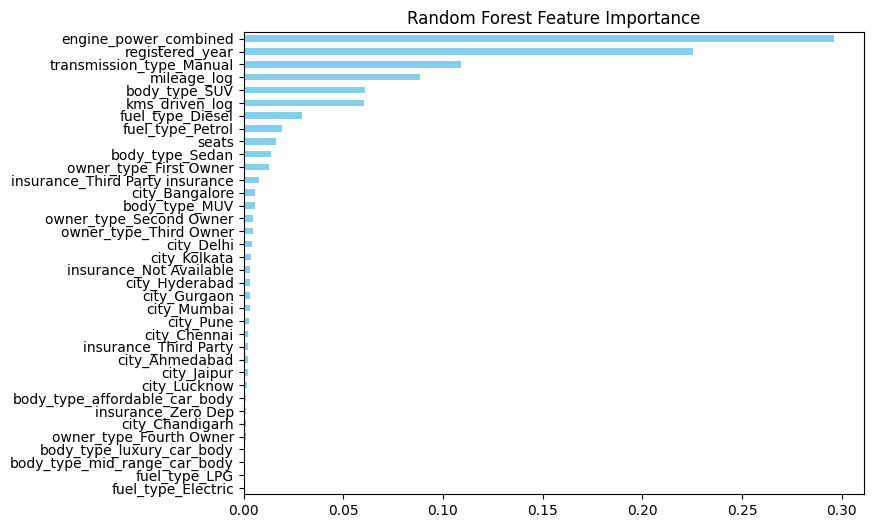

In [159]:
best_rf = grid_rf.best_estimator_

feat_imp_rf = pd.Series(best_rf.feature_importances_, index=X_train4.columns)
feat_imp_rf.sort_values(ascending=True).plot(kind='barh', figsize=(8,6), color='skyblue')
plt.title("Random Forest Feature Importance")
plt.show()


In [160]:
top_features_rf = ['engine_power_combined', 'registered_year', 'mileage_log',
                'body_type_SUV', 'transmission_type_Manual']
X_train4_top = X_train4[top_features]
X_test4_top = X_test4[top_features]

In [161]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['log2', 'sqrt']
}
rf = RandomForestRegressor(random_state=42)

grid_rf2 = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
grid_rf2.fit(X_train_top, y_train3)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_features': ['log2', 'sqrt'],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [162]:
best_rf2 = grid_rf2.best_estimator_

print("Best parameters:", grid_rf2.best_params_)
print("Best CV R²:", grid_rf2.best_score_)

y_train_pred_rf = best_rf2.predict(X_train_top)
y_test_pred_rf  = best_rf2.predict(X_test_top)

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Train R²:", round(r2_score(y_train3, y_train_pred_rf), 2))
print("Test R² :", round(r2_score(y_test3, y_test_pred_rf), 2))
print("Train RMSE:", round(np.sqrt(mean_squared_error(y_train3, y_train_pred_rf)), 2))
print("Test RMSE :", round(np.sqrt(mean_squared_error(y_test3, y_test_pred_rf)), 2))

Best parameters: {'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV R²: 0.9263100559661137
Train R²: 0.97
Test R² : 0.93
Train RMSE: 0.14
Test RMSE : 0.21
